# Import libraries

In [1]:
import numpy as np
import pandas as pd
import re
import ssl
import nltk
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

# Load CSVs from the /data directory

In [2]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

# Preview structure


In [3]:
df_train.head()
df_test.head()

,id,review,label
0,0,Once again Mr. Costner has dragged out a movie...,0
1,1,This is an example of why the majority of acti...,0
2,2,"First of all I hate those moronic rappers, who...",0
3,3,Not even the Beatles could write songs everyon...,0
4,4,Brass pictures (movies is not a fitting word f...,0


# Check Data Attributes and Types

In [4]:
print(df_train.info())

print(df_train['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      75000 non-null  int64 
 1   review  75000 non-null  object
 2   label   75000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.7+ MB
None
label
-1    50000
 0    12500
 1    12500
Name: count, dtype: int64


# Check for Missing Values and Quality Issues

In [5]:
# Null/missing values
print("Missing values (train):")
print(df_train.isnull().sum())

print("Missing values (test):")
print(df_test.isnull().sum())


Missing values (train):
id        0
review    0
label     0
dtype: int64
Missing values (test):
id        0
review    0
label     0
dtype: int64


There are no missing values in either train or test datasets.
All rows contain valid IDs, reviews, and labels.

=> Don’t need to drop or impute any data at this stage

In [6]:
# Check review length distribution
df_train['review_length'] = df_train['review'].apply(lambda x: len(str(x).split()))
df_train['review_length'].describe()

count    75000.00000
mean       234.21816
std        173.75620
min          9.00000
25%        127.00000
50%        175.00000
75%        285.00000
max       2470.00000
Name: review_length, dtype: float64

Most reviews are between 127–285 words (Q1–Q3).

Mean = 234, Max = 2470 → right-skewed distribution.

# Check for Duplicate Values

In [7]:
# Checking for duplicate values
# training 
print("Number of rows before removing duplicates (train):", len(df_train))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (train):", len(df_train))

# test 
print("Number of rows before removing duplicates (test):", len(df_test))
df_train.drop_duplicates(inplace=True)
print("Number of rows after removing duplicates (test):", len(df_test))


Number of rows before removing duplicates (train): 75000
Number of rows after removing duplicates (train): 75000
Number of rows before removing duplicates (test): 25000
Number of rows after removing duplicates (test): 25000


As a result, we know that there are no duplicate values exist in those DataFrames.

# Text Preprocessing

In [8]:
# Eliminate html tags
# Covert the text to lowercase.
# Remove the punctuation

def preprocess_text(text):
    # Remove HTML tags
    text = re.sub(r"<.*>", " ", text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation using regex
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_train['review'] = df_train['review'].apply(preprocess_text)
df_test['review'] = df_test['review'].apply(preprocess_text)

After preproccesing, the datasets don't contain any uppercase letters and punctuation.

# Eliminate stopwords and apply stemming or lemmatization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords list
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Build function
def tokenizer(text):
    tokens = re.findall(r'\b\w+\b', text.lower())
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return tokens

# Apply to dataset
df_train['tokens'] = df_train['review'].apply(tokenizer)
df_test['tokens'] = df_test['review'].apply(tokenizer)

# Display results
df_train[['review', 'tokens']].head()


,review,tokens
0,story of a man who has unnatural feelings for ...,"[story, man, unnatural, feelings, pig, starts,..."
1,airport 77 starts as a brand new luxury 747 pl...,"[airport, 77, starts, brand, new, luxury, 747,..."
2,this film lacked something i couldnt put my fi...,"[film, lacked, finger, charisma, leading, actr..."
3,sorry everyone i know this is supposed to be a...,"[sorry, know, supposed, art, film, wow, handed..."
4,when i was little my parents took me along to ...,"[little, parents, took, theater, interiors, mo..."


# Visualize class distributions (positive vs. negative reviews)

### Use sentiment analysis to differentiate the reviews with label -1 are postive (1) or negative (0)

In [10]:
# Download the vander_lexicon package for sentiment analusis
# Temporarily disable SSL certificate verification in case download problem
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
# If the older version of Python doesn't support unverified contexts
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
train_sentiment_analyzer = SentimentIntensityAnalyzer()

# classify sentiment
def classify_sentiment(text):
    scores = train_sentiment_analyzer.polarity_scores(text)
    compound = scores['compound']
    # negative label = 0
    # positive lable = 1
    if compound >= 0:
        return 1
    else:
        return 0    

In [12]:
# Apply classification with the label equal to -1 (unsup)
# It will takes few minutes to run
mask = df_train['label'] == -1
df_train.loc[mask, 'label'] = df_train.loc[mask, 'review'].apply(classify_sentiment)

In [13]:
df_train['label'].value_counts()

label
1    45186
0    29814
Name: count, dtype: int64

As a result, we can see there is no more review with label = -1

# Visualization

## Sentiment Distribution in Training Data

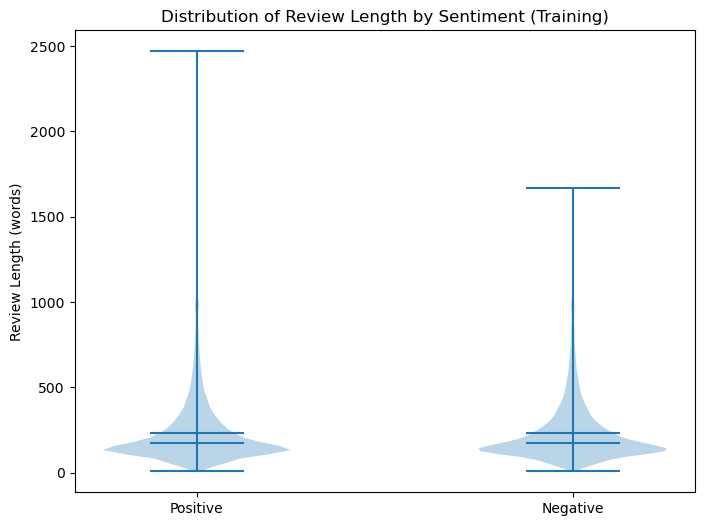

In [14]:
# positive = 1, negative = 0
df_train_positive = df_train[df_train['label'] == 1]['review_length']
df_train_negative = df_train[df_train['label'] == 0]['review_length']

# Combine data into a list
list_train_visualization = [df_train_positive, df_train_negative]

# Create the violin plot
fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot(list_train_visualization, showmeans=True, showmedians=True)

# Set custom x-tick labels
ax.set_xticks([1, 2])
ax.set_xticklabels(['Positive', 'Negative'])

# Add labels and title
ax.set_ylabel('Review Length (words)')
ax.set_title('Distribution of Review Length by Sentiment (Training)')

plt.show()

As result we can see that:
- Postive reviews have a wider range, extending up to 2500 words compare to Negative only have closely 1500 words.

- According with median we can see each sentiment has almost same distribution.

- Some positive reviewers tends to write very long reivews.


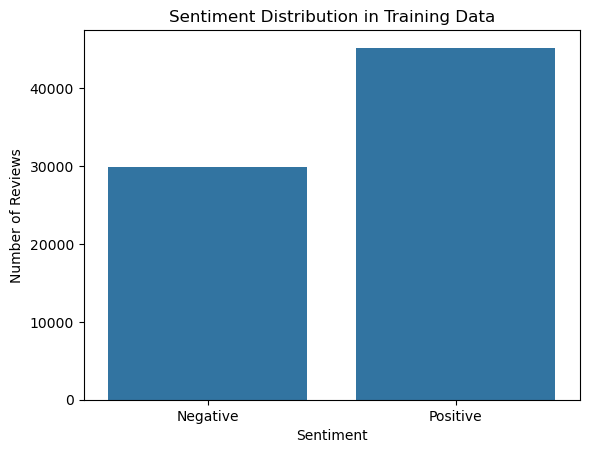

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_train, x='label')
plt.title('Sentiment Distribution in Training Data')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.ylabel('Number of Reviews')
plt.xlabel('Sentiment')
plt.show()


## Wordcloud by Feeling

Word Clouds:

- Clear semantic difference between positive and negative reviews.

- Positive = emotional, descriptive terms like “love”, “great”

- Negative = critical terms like “boring”, “waste”, “bad”

In [16]:
from wordcloud import WordCloud

# Convert words lists to text
positive_text = " ".join(positive_words)
negative_text = " ".join(negative_words)

# Create word clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
wordcloud_negative = WordCloud(width=800, height=400, background_color="black").generate(negative_text)

# Build the plot
fig, ax = plt.subplots(1, 2, figsize=(15,6))

ax[0].imshow(wordcloud_positive, interpolation='bilinear')
ax[0].set_title("Word Cloud - Positive Reviews")
ax[0].axis("off")

ax[1].imshow(wordcloud_negative, interpolation='bilinear')
ax[1].set_title("Word Cloud - Negative Reviews")
ax[1].axis("off")

plt.show()

NameError: name 'positive_words' is not defined

# Generate word frequency distributions.

In [ ]:
from collections import Counter

# Obtain positive and negative words from each class
positive_words = [word for tokens in df_train[df_train["label"] == 1]["tokens"] for word in tokens]
negative_words = [word for tokens in df_train[df_train["label"] == 0]["tokens"] for word in tokens]

# Register frequency
positive_freq = Counter(positive_words)
negative_freq = Counter(negative_words)

# Convert to dataframe for visualization
df_positive_freq = pd.DataFrame(positive_freq.most_common(20), columns=['Word', 'Frequency'])
df_negative_freq = pd.DataFrame(negative_freq.most_common(20), columns=['Word', 'Frequency'])

# Display top20 frequent words for each category
print("Top 20 words for positive reviews")
print(df_positive_freq)
print("\nTop 20 words for negative reviews")
print(df_negative_freq)

Top 20 words for positive reviews
      Word  Frequency
0    movie      50011
1     film      46332
2     like      21331
3     good      18619
4     just      17136
5    great      14702
6     time      13346
7    story      13129
8   really      12548
9    films       9996
10  movies       9802
11    best       9580
12    love       9361
13  people       9269
14   watch       9045
15    dont       8581
16   think       8144
17    seen       8057
18     way       8039
19    make       7768

Top 20 words for negative reviews
      Word  Frequency
0    movie      38581
1     film      28128
2     just      14651
3     like      14490
4      bad      12211
5     good       9628
6     time       9235
7   really       8921
8     dont       7858
9    story       7198
10  movies       7014
11  people       6975
12    make       6286
13   watch       6123
14  acting       5768
15   films       5713
16    seen       5645
17    plot       5608
18     way       5479
19   think       5154


Top Frequent Words by Sentiment:

- Positive: movie, good, great, best, love

- Negative: movie, bad, boring, worst, waste

#  Split the dataset

In [ ]:
from sklearn.model_selection import train_test_split

df_train_split, df_val_split = train_test_split(
    df_train,
    test_size=0.2,
    stratify=df_train['label'],
    random_state=42
)

# Implement Bag of Words (BoW) feature extraction.​

In [ ]:
# Implement BoW feature model
# Convert the the review to numerical data (matrix, vector) based on frequency
BoW_vectorizer = CountVectorizer()
train_review_text = BoW_vectorizer.fit_transform(df_train_split['review'])
test_review_text  = BoW_vectorizer.transform(df_test['review'])
val_review_text = BoW_vectorizer.transform(df_val_split['review'])

# Apply Term Frequency-Inverse Document Frequency (TF-IDF) transformation.​

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

# Build TF-IDF transformer
tfidf_transformer = TfidfTransformer()

# Apply transformation to data
train_tfidf = tfidf_transformer.fit_transform(train_review_text)
test_tfidf = tfidf_transformer.transform(test_review_text)
val_tfidf = tfidf_transformer.transform(val_review_text)

After implement the BoW and TF-IDF, We can use the data to train a machine Learning model

# Split dataset after TF-IDF 

In [ ]:
X_train = train_tfidf
y_train = df_train_split['label']
X_test = test_tfidf
y_test = df_test['label']
X_val = val_tfidf
y_val = df_val_split['label']

# Train baseline models: Naive Bayes.​

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
# Same process logic as the logistic model
nb_model.fit(X_train, y_train)
nb_predict_val = nb_model.predict(X_val)
print(classification_report(y_val, nb_predict_val))
print("Accuracy:", accuracy_score(y_val, nb_predict_val))

              precision    recall  f1-score   support

           0       0.91      0.16      0.28      5963
           1       0.64      0.99      0.78      9037

    accuracy                           0.66     15000
   macro avg       0.78      0.58      0.53     15000
weighted avg       0.75      0.66      0.58     15000

Accuracy: 0.6616


As a result, the Logistic Regression model has higher accuracy compare to the Naive Bayes model

## Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

clf = LinearSVC(random_state=42, max_iter=5000)
clf.fit(X_train, y_train)
clf_predict_val = clf.predict(X_val)

print(classification_report(y_val, clf_predict_val))
print("Accuracy:", accuracy_score(y_val, clf_predict_val))

              precision    recall  f1-score   support

           0       0.77      0.73      0.75      5963
           1       0.83      0.85      0.84      9037

    accuracy                           0.81     15000
   macro avg       0.80      0.79      0.80     15000
weighted avg       0.80      0.81      0.80     15000

Accuracy: 0.8053333333333333


## CNN

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 1: Initialize tokenizer
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')  # keep top 20,000 words
tokenizer.fit_on_texts(df_train_split['review'])  # fit on training reviews

# Step 2: Convert reviews to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(df_train_split['review'])
X_val_seq   = tokenizer.texts_to_sequences(df_val_split['review'])
X_test_seq = tokenizer.texts_to_sequences(df_test['review'])


# Step 3: Pad sequences to make them all the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=300, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=300, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=300, padding='post')


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

model = Sequential([
    Embedding(input_dim=20000, output_dim=64, input_length=300),
    Conv1D(64, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=3, batch_size=64)


c:\Users\admin\anaconda3\envs\imdb-nlp\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.6804 - loss: 0.5890 - val_accuracy: 0.7875 - val_loss: 0.4718
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8305 - loss: 0.4041 - val_accuracy: 0.7935 - val_loss: 0.4483
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9042 - loss: 0.2721 - val_accuracy: 0.7886 - val_loss: 0.5020


In [ ]:
# Predict on validation or test set
cnn_pred_prob = model.predict(X_test_pad)  # returns probabilities
cnn_pred = (cnn_pred_prob > 0.5).astype(int).reshape(-1)  # convert to 0/1


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
print(classification_report(y_test, cnn_pred))
print("Accuracy:", accuracy_score(y_test, cnn_pred))

              precision    recall  f1-score   support

           0       0.84      0.65      0.73     12500
           1       0.71      0.88      0.79     12500

    accuracy                           0.76     25000
   macro avg       0.78      0.76      0.76     25000
weighted avg       0.78      0.76      0.76     25000

Accuracy: 0.76268


# Analyze confusion matrices for each model.

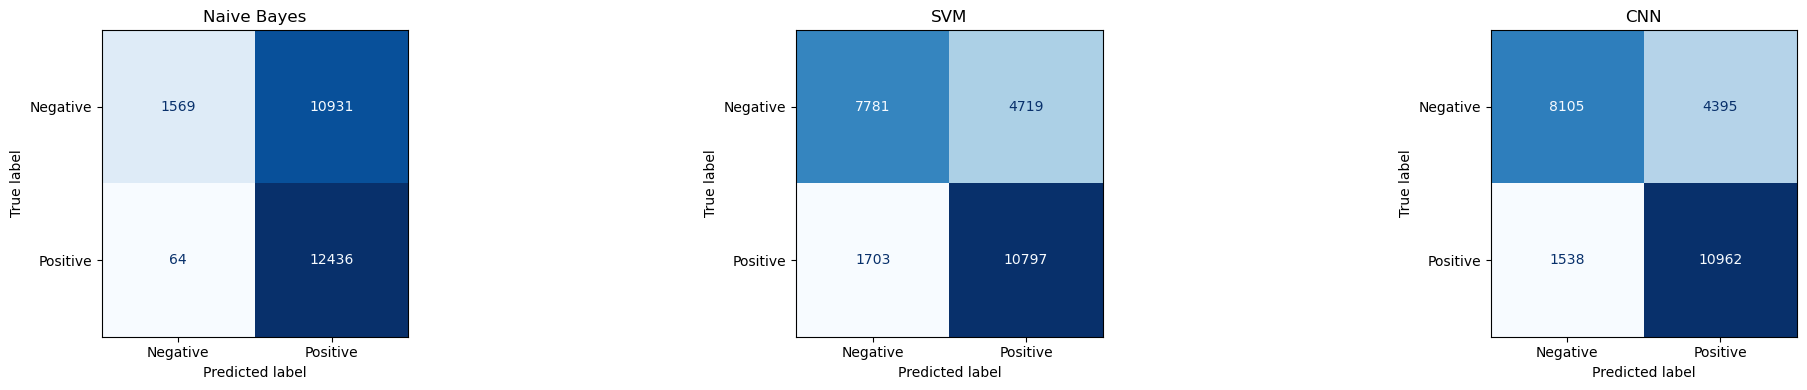

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


nb_predict_test = nb_model.predict(X_test)
clf_predict_test = clf.predict(X_test)


fig, axs = plt.subplots(1, 3, figsize=(22, 4))

models = {
    "Naive Bayes": nb_predict_test,
    "SVM": clf_predict_test,
    "CNN": cnn_pred
}

for ax, (name, preds) in zip(axs, models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


# Analysis F1 score and recall score

## F1 score

In [ ]:
from sklearn.metrics import f1_score

# print("Logistic Regression:", f1_score(y_test, logistic_predict_test))
print("Naive Bayes:", f1_score(y_test, nb_predict_test))
print("Support Vector Machines:", f1_score(y_test, clf_predict_test))
# print("Random Forest:", f1_score(y_test, rf_predict_test))
print("CNN:", f1_score(y_test, cnn_pred))


Naive Bayes: 0.6934508043605543
Support Vector Machines: 0.7707738435179897
CNN: 0.7870194206124134


Based on F1 score, the best model for our data is Logistic Regression

# Analysis accuracy score and precision score

## Accuracy score 

In [ ]:
# Accuracy Score
print("Accuracy Score:")
# print("Logistic Regression:", accuracy_score(y_test, logistic_predict_test))
print("Naive Bayes:", accuracy_score(y_test, nb_predict_test))
print("Support Vector Machine:", accuracy_score(y_test, clf_predict_test))
# print("Random Forest:", accuracy_score(y_test, rf_predict_test))
print("CNN:", accuracy_score(y_test, cnn_pred))


Accuracy Score:
Naive Bayes: 0.5602
Support Vector Machine: 0.74312
CNN: 0.76268


## Precision score

In [ ]:
from sklearn.metrics import precision_score
print('Precision Score:')
# print("Logistic Regression:", precision_score(y_test, logistic_predict_test))
print("Naive Bayes:", precision_score(y_test, nb_predict_test))
print("Support Vector Machine:", precision_score(y_test, clf_predict_test))
# print("Random Forest:", precision_score(y_test, rf_predict_test))
print("CNN:", precision_score(y_test, cnn_pred))

Precision Score:
Naive Bayes: 0.5322035348996448
Support Vector Machine: 0.695862335653519
CNN: 0.7138112912678257


Based on the accuracy and precision scores, the best model for our data is still Logistic Regression

# Recall

In [ ]:
from sklearn.metrics import recall_score
print('Classification Report:')
# print("Logistic Regression:", recall_score(y_test, logistic_predict_test))
print("Naive Bayes:", recall_score(y_test, nb_predict_test))
print("Support Vector Machine:", recall_score(y_test, clf_predict_test))
# print("Random Forest:", recall_score(y_test, rf_predict_test))
print("CNN:", recall_score(y_test, cnn_pred))

Classification Report:
Naive Bayes: 0.99488
Support Vector Machine: 0.86376
CNN: 0.87696


Based on the recall score, the best model for our data is Naive Bayes.

# Perform hyperparameter tuning for baseline models.​

## Naive Bayes Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
# Define parameter grid for Naive Bayes
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0]  # Smoothing parameter
}

# GridSearchCV with 5-fold CV, optimizing for accuracy
grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',  # or 'f1' if that's your priority
    n_jobs=-1
)

# Fit the grid on the training set
grid_nb.fit(X_train, y_train)

# Best estimator from the grid
best_nb_model = grid_nb.best_estimator_

# Predict on the test set
nb_preds = best_nb_model.predict(X_test)

print("=== Naive Bayes (Tuned) ===\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, nb_preds))

# Calculate specific metrics on the test set
test_accuracy = accuracy_score(y_test, nb_preds)
test_f1 = f1_score(y_test, nb_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}\n")

# Display cross-validation results from the best model
print("=== Cross-Validation Results ===")
print(f"Best Cross-Val Accuracy: {grid_nb.best_score_:.4f}")  # This is the best average CV score
print("Best Hyperparameters:", grid_nb.best_params_)

=== Naive Bayes (Tuned) ===

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.88      0.52      0.65     12500
           1       0.66      0.93      0.77     12500

    accuracy                           0.72     25000
   macro avg       0.77      0.72      0.71     25000
weighted avg       0.77      0.72      0.71     25000

Test Accuracy: 0.7230
Test F1 Score: 0.7700

=== Cross-Validation Results ===
Best Cross-Val Accuracy: 0.7526
Best Hyperparameters: {'alpha': 0.1}


## SVM Tuning

In [ ]:
from sklearn.svm import LinearSVC
# Parameter grid for LinearSVC
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge']
}

# GridSearchCV with 5-fold cross-validation.
# scoring='accuracy' will pick the best hyperparams for accuracy.
# For an F1-optimized model, change to scoring='f1'.
grid_svm = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on training set
grid_svm.fit(X_train, y_train)

# Best estimator from the grid
best_svm_model = grid_svm.best_estimator_

# Predict on the test set
svm_preds = best_svm_model.predict(X_test)

print("=== Support Vector Machine (Tuned) ===\n")
print("Classification Report on Test Set:")
print(classification_report(y_test, svm_preds))

# Compute key metrics on the test set
test_accuracy = accuracy_score(y_test, svm_preds)
test_f1 = f1_score(y_test, svm_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}\n")

# Display cross-validation results from GridSearchCV
print("=== Cross-Validation Results ===")
print(f"Best Cross-Val Score: {grid_svm.best_score_:.4f}")  # This is accuracy across folds
print("Best Hyperparameters:", grid_svm.best_params_)

=== Support Vector Machine (Tuned) ===

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.84      0.62      0.71     12500
           1       0.70      0.88      0.78     12500

    accuracy                           0.75     25000
   macro avg       0.77      0.75      0.75     25000
weighted avg       0.77      0.75      0.75     25000

Test Accuracy: 0.7503
Test F1 Score: 0.7791

=== Cross-Validation Results ===
Best Cross-Val Score: 0.8017
Best Hyperparameters: {'C': 1, 'loss': 'hinge'}


# CNN Optimization

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)  # For reproducibility

# 1. Define model-building function to be reused with different hyperparams
def create_cnn_model(embedding_dim=64, filters=64, kernel_size=5):
    model = Sequential([
        Embedding(input_dim=20000, output_dim=embedding_dim, input_length=300),
        Conv1D(filters, kernel_size, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])
    return model

# 2. Parameter grid
configs = [
    {"embedding_dim": 64, "filters": 64, "kernel_size": 5},
    {"embedding_dim": 128, "filters": 64, "kernel_size": 3},
    {"embedding_dim": 64, "filters": 128, "kernel_size": 3},
    {"embedding_dim": 128, "filters": 128, "kernel_size": 5}
]

# 3. Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# 4. Run training + evaluation for each config
results = []

for i, cfg in enumerate(configs, 1):
    print(f"\n🔧 Config {i}: {cfg}")
    
    model = create_cnn_model(**cfg)
    
    model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=5,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    preds = model.predict(X_test_pad)
    preds = (preds >= 0.5).astype(int).reshape(-1)  # ← prediction fix here

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    print(f"✅ Accuracy: {acc:.4f} | F1 Score: {f1:.4f}")
    
    results.append({
        "Config": cfg,
        "Accuracy": acc,
        "F1 Score": f1,
        "Model": model
    })

# 📌 After training all models, find the best one
best_result = max(results, key=lambda x: x['F1 Score'])
best_model = best_result['Model']

print("\n🏆 Best Model Found!")
print(f"Config: {best_result['Config']}")
print(f"Accuracy: {best_result['Accuracy']:.4f} | F1 Score: {best_result['F1 Score']:.4f}")



🔧 Config 1: {'embedding_dim': 64, 'filters': 64, 'kernel_size': 5}


c:\Users\admin\anaconda3\envs\imdb-nlp\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
✅ Accuracy: 0.7531 | F1 Score: 0.7857

🔧 Config 2: {'embedding_dim': 128, 'filters': 64, 'kernel_size': 3}


c:\Users\admin\anaconda3\envs\imdb-nlp\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
✅ Accuracy: 0.7653 | F1 Score: 0.7949

🔧 Config 3: {'embedding_dim': 64, 'filters': 128, 'kernel_size': 3}


c:\Users\admin\anaconda3\envs\imdb-nlp\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
✅ Accuracy: 0.7821 | F1 Score: 0.7973

🔧 Config 4: {'embedding_dim': 128, 'filters': 128, 'kernel_size': 5}


c:\Users\admin\anaconda3\envs\imdb-nlp\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
✅ Accuracy: 0.7576 | F1 Score: 0.7895

🏆 Best Model Found!
Config: {'embedding_dim': 64, 'filters': 128, 'kernel_size': 3}
Accuracy: 0.7821 | F1 Score: 0.7973


# Compare performance metrics across all models

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Collect model names and their predictions on X_test
# Because tune is better than baseline, we only show tuned models here.
# (You can add the baseline models if you want to compare them too.)
model_preds = {
    # "Naive Bayes (baseline)":        nb_predict_test,
    # "SVM (baseline)":                clf_predict_test,
    # "CNN (baseline)":                cnn_pred,
    "Naive Bayes (tuned)":           nb_preds,
    "SVM (tuned)":                   svm_preds,
    "CNN (tuned)":                   (best_model.predict(X_test_pad) >= 0.5).astype(int),
    # (If you have optimized CNN configs, add them here too, e.g. "CNN cfg1": preds1, etc.)
}

# 2. Define a helper to compute metrics
def compute_metrics(y_true, y_pred):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred)
    }

# 3. Build a DataFrame of results
import pandas as pd

records = []
for name, preds in model_preds.items():
    m = compute_metrics(y_test, preds)
    records.append({
        "Model":    name,
        "Accuracy": m["accuracy"],
        "Precision":m["precision"],
        "Recall":   m["recall"],
        "F1 Score": m["f1"]
    })

results_df = pd.DataFrame.from_records(records)
results_df = results_df.sort_values("F1 Score", ascending=False)  # sort by your primary metric

print("\n=== Comparison of All Models ===")
print(results_df.to_markdown(index=False))

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

=== Comparison of All Models ===
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |
|:--------------------|-----------:|------------:|---------:|-----------:|
| CNN (tuned)         |    0.78212 |    0.745458 |  0.8568  |   0.797261 |
| SVM (tuned)         |    0.75028 |    0.698421 |  0.88096 |   0.779142 |
| Naive Bayes (tuned) |    0.723   |    0.658282 |  0.92744 |   0.770018 |


## Model Performance Table

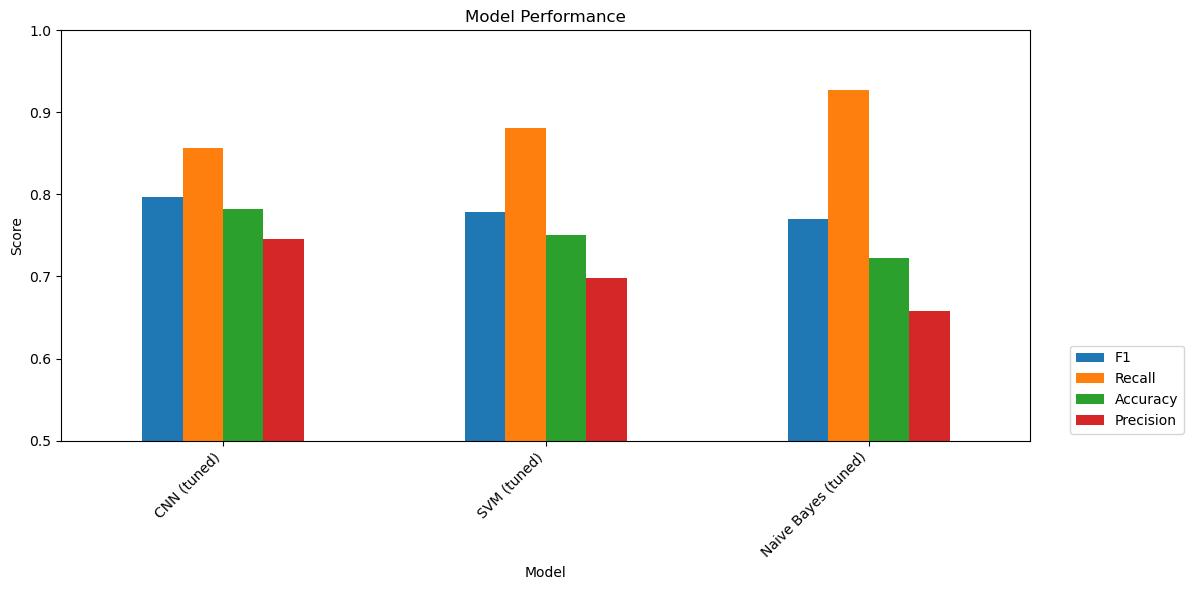

In [ ]:
# 1. Sort results_df for nicer plotting (optional)
results_df_sorted = results_df.sort_values(by='F1 Score', ascending=False)

# 2. Create the summary DataFrame
summary_df = pd.DataFrame({
    "Model": results_df_sorted['Model'],
    "F1": results_df_sorted['F1 Score'],
    "Recall": results_df_sorted['Recall'],
    "Accuracy": results_df_sorted['Accuracy'],
    "Precision": results_df_sorted['Precision']
})

# 3. Set 'Model' as index for plotting
summary_df.set_index("Model").plot(kind="bar", figsize=(12,6), title="Model Performance")

# 4. Make it pretty
plt.xticks(rotation=45, ha='right')  # Rotate x-labels for better spacing
plt.legend(loc="lower center", bbox_to_anchor=(1.1,0))
plt.ylim(0.5, 1.0)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

=> Best Choice: CNN

Reason:

Highest F1 Score (0.792) → best balance between Precision and Recall.

Highest Accuracy (0.76372) → best correct predictions overall.

Very good Recall (0.900) → catches almost all positives.

Good Precision (0.707) → not too many false positives.

# Testing part

In [ ]:
# Your custom reviews
custom_reviews = [
    "This movie was incredibly touching and well-acted.",
    "I fell asleep halfway through. Very boring.",
    "Absolutely fantastic! A must-watch.",
    "The worst movie I've ever seen."
]

# 🛠 Preprocessing: tokenize + pad (similar to how you processed X_train)
# If you used keras tokenizer and padding, do like this:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Use the tokenizer that was fitted on your train set!
# Example: tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>") → it should already exist.

# Tokenize
sequences = tokenizer.texts_to_sequences(custom_reviews)

# Pad
custom_reviews_pad = pad_sequences(sequences, maxlen=300)

# 📈 Predict
predictions = best_model.predict(custom_reviews_pad)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)

# 🎯 Display results
for review, pred in zip(custom_reviews, predicted_labels):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Review: This movie was incredibly touching and well-acted.
Predicted Sentiment: Positive

Review: I fell asleep halfway through. Very boring.
Predicted Sentiment: Negative

Review: Absolutely fantastic! A must-watch.
Predicted Sentiment: Positive

Review: The worst movie I've ever seen.
Predicted Sentiment: Negative

